# Week 3 lab -->EDA

Topics: Univariate and multivariate analysis, correlations.

 Problems:

 (a) Plot histograms, bar charts, and scatter plots.

 (b) Generate 
correlation heatmap

. (c) Identify features with strong correlation to target 
variable. 

## Import liberaries and load dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Iris_Cleaned.csv")
print('Basic EDA on iris dataset \n\n')
print(df.head())

print('\n\nDataset Columns')
print(df.columns)

print('\n\nDataset information')
print(df.info())
#remove species_encoded column from the dataste 
print('\n\nRemoving Species encoded Column')
df = df.drop("species_enc",axis=1)
df.head()

Basic EDA on iris dataset 


   sepal_length  sepal_width  petal_length  petal_width species  species_enc
0           5.1          3.5           1.4          0.2  Setosa            0
1           4.9          3.0           1.4          0.2  Setosa            0
2           4.7          3.2           1.3          0.2  Setosa            0
3           4.6          3.1           1.5          0.2  Setosa            0
4           5.0          3.6           1.4          0.2  Setosa            0


Dataset Columns
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species',
       'species_enc'],
      dtype='object')


Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  147 non-null    float64
 1   sepal_width   147 non-null    float64
 2   petal_length  147 non-null    float64
 3   petal_width   147 no

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## Univariate Analysis 

Univariate Analysis


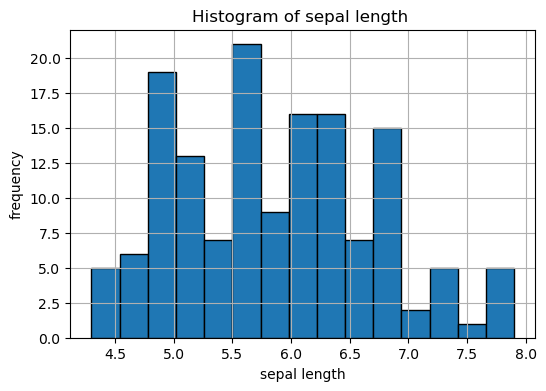

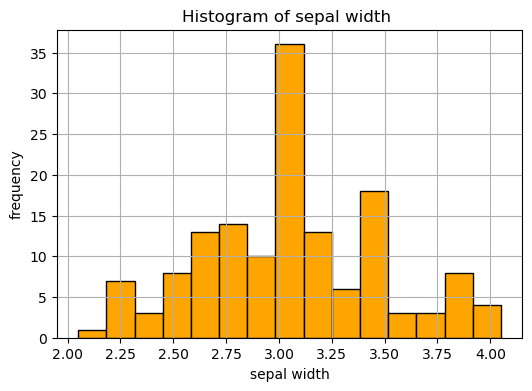

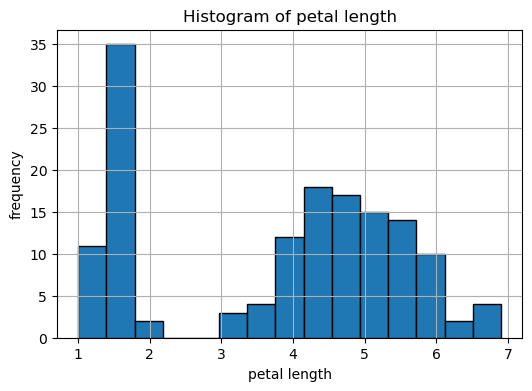

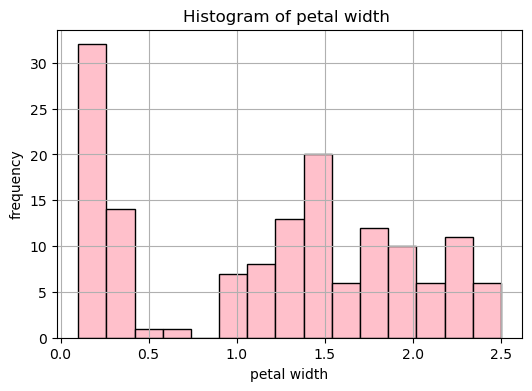

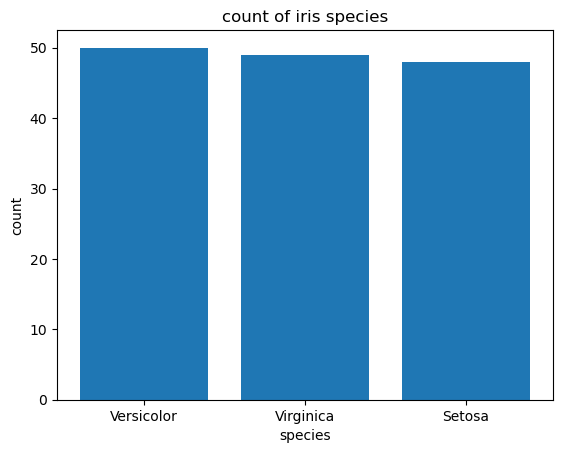

In [2]:
# Analysis of sepal length
print('Univariate Analysis')
plt.figure(figsize = (6,4))
plt.grid()
plt.hist(df['sepal_length'],
            bins = 15,
            edgecolor = 'black')
plt.title('Histogram of sepal length ')
plt.xlabel('sepal length')
plt.ylabel('frequency')
plt.show()

#Analysis of sepal width
plt.figure(figsize = (6,4))
plt.grid()
plt.hist(df['sepal_width'],
            bins = 15,
            color = 'orange',
            edgecolor = 'black')
plt.title('Histogram of sepal width ')
plt.xlabel('sepal width')
plt.ylabel('frequency')
plt.show()

# Analysis of petal length
plt.figure(figsize = (6,4))
plt.grid()
plt.hist(df['petal_length'],
            bins = 15,
            edgecolor = 'black')
plt.title('Histogram of petal length')
plt.xlabel('petal length')
plt.ylabel('frequency')
plt.show()

#Analysis of sepal width
plt.figure(figsize = (6,4))
plt.grid()
plt.hist(df['petal_width'],
            bins = 15,
            color = 'pink',
            edgecolor = 'black')
plt.title('Histogram of petal width ')
plt.xlabel('petal width')
plt.ylabel('frequency')
plt.show()



#Analysis of categorical data --> species 
species_count = df['species'].value_counts()
plt.bar(species_count.index, species_count.values)
plt.title("count of iris species")
plt.xlabel("species")
plt.ylabel("count")
plt.show()            #All species have equal counts 
# print(species_count)

## Multivariate analysis 

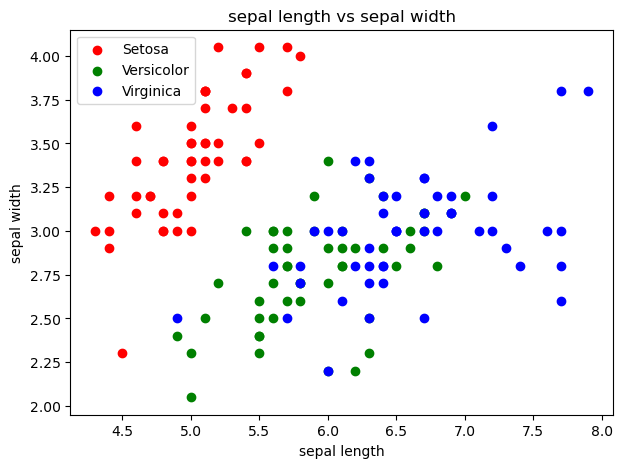

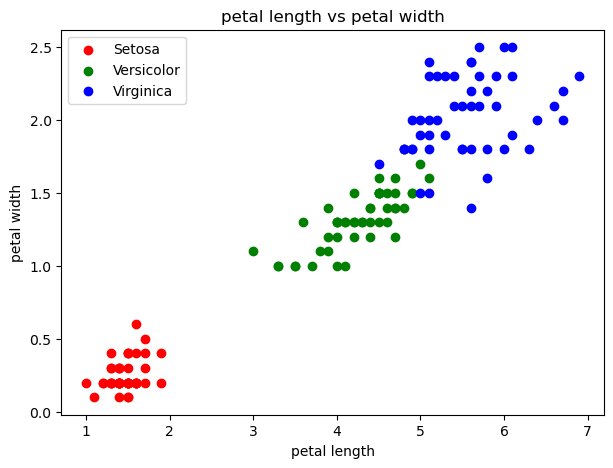

In [3]:
# create dictionary for colors 
colors = {
    'Setosa':'red',
    'Versicolor':'green',
    'Virginica':'blue'
}

plt.figure(figsize=(7,5))

for species in colors:
    subset = df[df['species'] == species]
    plt.scatter(
        subset['sepal_length'],
        subset['sepal_width'],
        color = colors[species],
        label = species
                )

plt.title("sepal length vs sepal width")
plt.xlabel("sepal length")
plt.ylabel("sepal width")
plt.legend()
plt.show()

plt.figure(figsize=(7,5))

for species in colors:
    subset = df[df['species'] == species]
    plt.scatter(
        subset['petal_length'],
        subset['petal_width'],
        color = colors[species],
        label = species
                )

plt.title("petal length vs petal width")
plt.xlabel("petal length")
plt.ylabel("petal width")
plt.legend()
plt.show()

## Correlation analysis 


correlation matrix


              sepal_length  sepal_width  petal_length  petal_width   species
sepal_length      1.000000    -0.110155      0.871305     0.817058  0.782904
sepal_width      -0.110155     1.000000     -0.420140    -0.355139 -0.417918
petal_length      0.871305    -0.420140      1.000000     0.961883  0.948339
petal_width       0.817058    -0.355139      0.961883     1.000000  0.955693
species           0.782904    -0.417918      0.948339     0.955693  1.000000


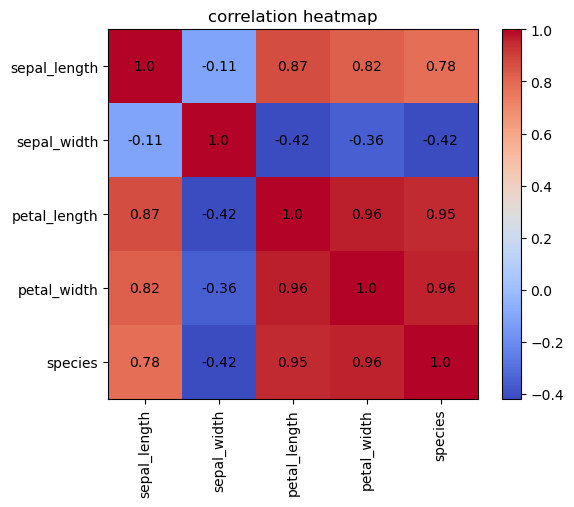

In [4]:
#correlation matrix 
df['species'] = df['species'].map({
    'Setosa':0,
    'Versicolor':1,
    'Virginica':2
})
print("\ncorrelation matrix\n\n")
correlation = df.corr()
print(correlation)

#heatmap 
plt.imshow(
    correlation,
    cmap='coolwarm'
)
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns,
)

plt.title("correlation heatmap")

#Display coelation values 
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            round(correlation.iloc[i,j],2),
            ha = 'center',
            va = 'center'
        )
plt.show()

## features stringly correlated with target

In [5]:
target_corr = correlation['species']
print(target_corr)

sepal_length    0.782904
sepal_width    -0.417918
petal_length    0.948339
petal_width     0.955693
species         1.000000
Name: species, dtype: float64
